# Retail Sales Data Analysis & Business Insights using Python

## Project Overview

This project analyzes a retail sales dataset using Python to uncover business insights through data cleaning, exploratory data analysis (EDA), and visualization.

### Objectives

- Understand the dataset
- Clean the data
- Perform exploratory data analysis
- Create meaningful visualizations
- Generate business insights


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

df.head()
df.shape

Saving Sample - Superstore.csv to Sample - Superstore.csv


(9994, 21)

In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity


### Observation

- The dataset contains 21 columns.
- It includes both numerical and categorical features.
- Date columns are currently stored as object data type.
- Some columns may require type conversion during preprocessing.

In [ ]:
# Statistical Summary

df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Observation

- Sales and Profit values vary significantly.
- Some products generate losses (negative profit).
- Discount values range from 0 to 0.8.

In [ ]:
# Missing Values

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Observation

- Check whether any columns contain missing values.
- If present, they will be handled during the data cleaning phase.

In [ ]:
# Duplicate Records

df.duplicated().sum()

np.int64(0)

### Observation

- Duplicate rows can affect the accuracy of analysis.
- These will be removed if found.

In [ ]:
# Column Names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
# Data Types

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


##  Data Cleaning

Data cleaning is an essential step before analysis. It ensures that the dataset is accurate, consistent, and ready for meaningful insights.

In [ ]:
# Convert date columns into datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date columns converted successfully.")

Date columns converted successfully.


### Observation

The Order Date and Ship Date columns have been converted into datetime format, enabling time-based analysis.

In [ ]:
# Remove duplicate rows

duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)

Duplicates before: 0
Duplicates after: 0


### Observation

Duplicate records were removed to improve data quality and avoid misleading analysis.

In [ ]:
# Check missing values

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### Observation

No missing values were found in the dataset.

In [ ]:
# Dataset shape after cleaning

df.shape

(9994, 21)

### Observation

The dataset was verified after cleaning to ensure that duplicate records were successfully removed.

# Key Performance Indicators (KPI Summary)

Before performing detailed analysis, let's calculate some important business metrics to get an overall understanding of the dataset.

In [ ]:
# Calculate KPIs

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
average_discount = df['Discount'].mean()
average_sales = df['Sales'].mean()

print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Total Profit       : ${total_profit:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Total Customers    : {total_customers}")
print(f"Average Sales      : ${average_sales:.2f}")
print(f"Average Discount   : {average_discount:.2%}")

Total Sales        : $2,297,200.86
Total Profit       : $286,397.02
Total Orders       : 5009
Total Customers    : 793
Average Sales      : $229.86
Average Discount   : 15.62%


### Observation

- The dataset contains overall business performance metrics.
- These KPIs provide a quick summary of sales, profit, customers, orders, and average discount before detailed analysis.

#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, trends, and relationships in the dataset before drawing business conclusions.

In [ ]:
# Sales by Category

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


## Analysis 1: Sales by Category

This analysis examines the total sales generated by each product category. It helps identify which category contributes the most to the company's revenue.

/tmp/ipykernel_3262/1846587238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


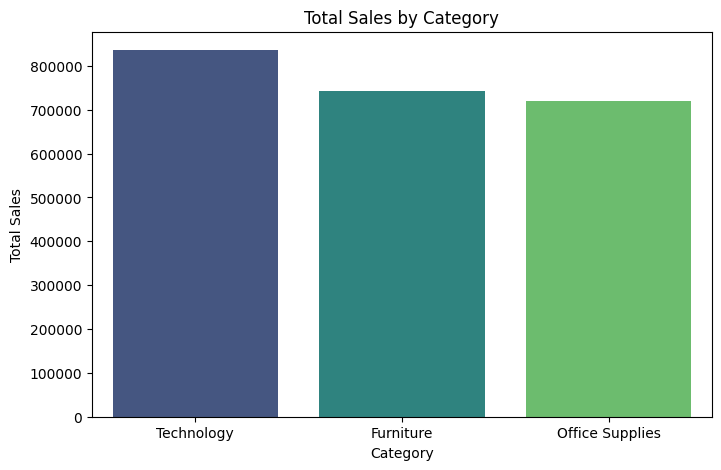

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette='viridis'
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Observation

- Technology generated the highest sales.
- Office Supplies recorded the lowest sales.
- Furniture contributed a significant portion of total sales.

### Business Insight

The company should continue investing in Technology products while exploring strategies to improve Office Supplies sales.

## Analysis 2: Profit by Category

This analysis compares the total profit earned from each product category. It helps identify the most profitable categories and those that require improvement.

In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


/tmp/ipykernel_3262/308004819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


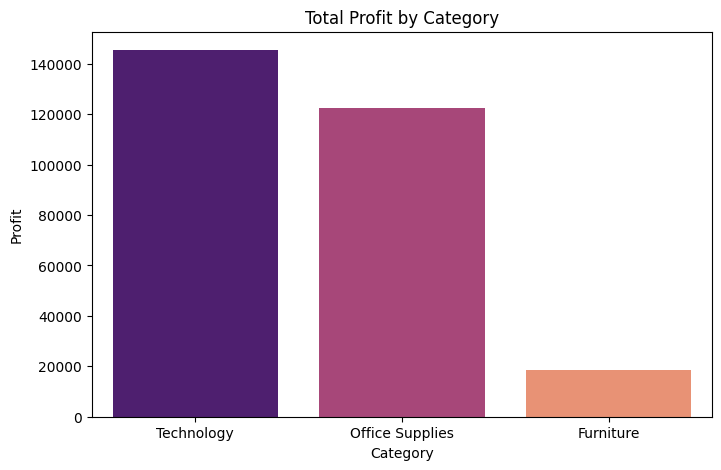

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_profit.index,
    y=category_profit.values,
    palette='magma'
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

### Observation

- Technology generated the highest overall profit.
- Furniture earned the lowest profit.

### Business Insight

Although Furniture contributes to sales, its profitability is comparatively lower. Pricing and discount strategies should be reviewed.

## Analysis 3: Sales by Region

This analysis evaluates sales performance across different regions. It helps identify high-performing and low-performing markets.

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


/tmp/ipykernel_3262/1733524141.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


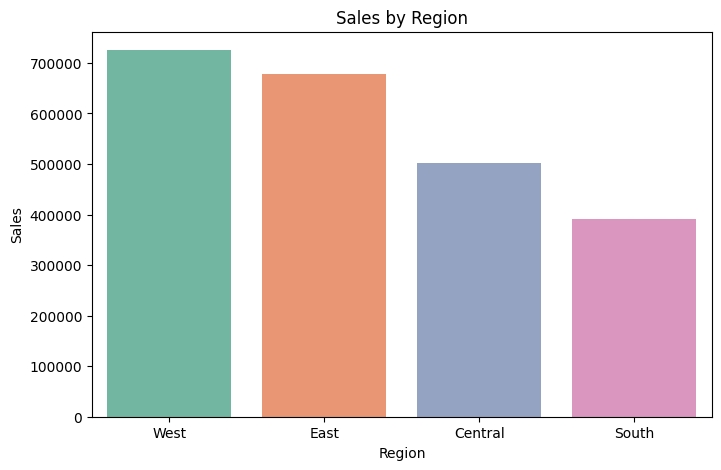

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette='Set2'
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

### Observation

- The West region generated the highest sales.
- The South region recorded comparatively lower sales.

### Business Insight

Marketing efforts can be increased in lower-performing regions to improve overall revenue.

## Analysis 4: Monthly Sales Trend

This analysis tracks monthly sales over time to identify seasonal trends, growth patterns, and fluctuations in revenue.

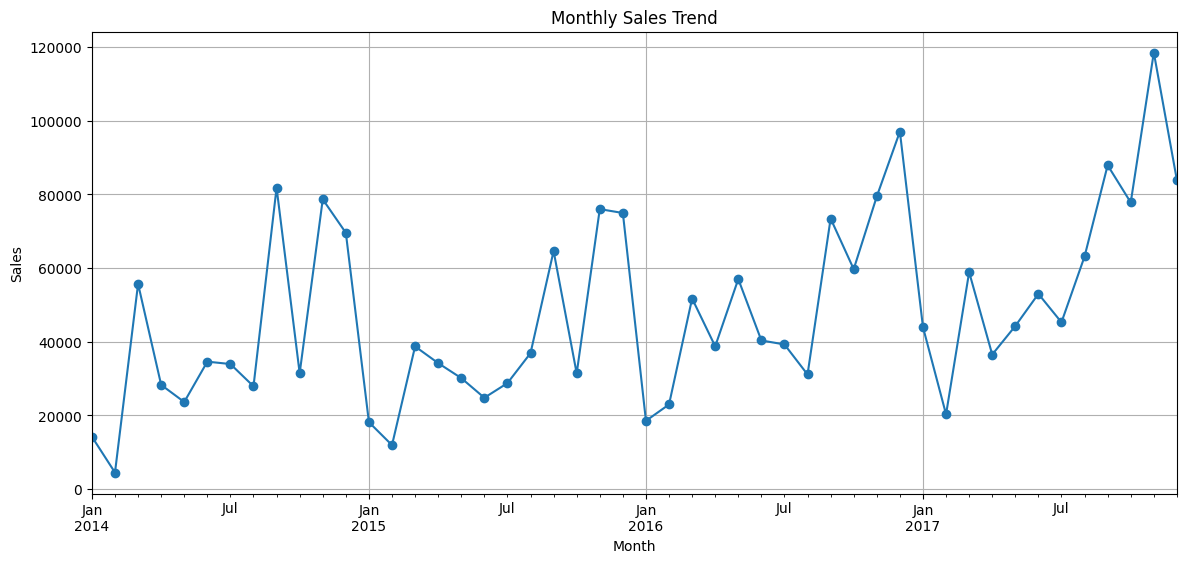

In [ ]:
# Create Month-Year column

df['Month_Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month_Year')['Sales'].sum()

monthly_sales

plt.figure(figsize=(14,6))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

- Monthly sales fluctuate throughout the year.
- Certain months experience significantly higher sales.

### Business Insight

The company should identify the reasons behind peak sales months and apply similar strategies during low-performing months.

## Analysis 5: Monthly Profit Trend

This analysis examines how profit changes over time and compares it with sales performance to understand business profitability.

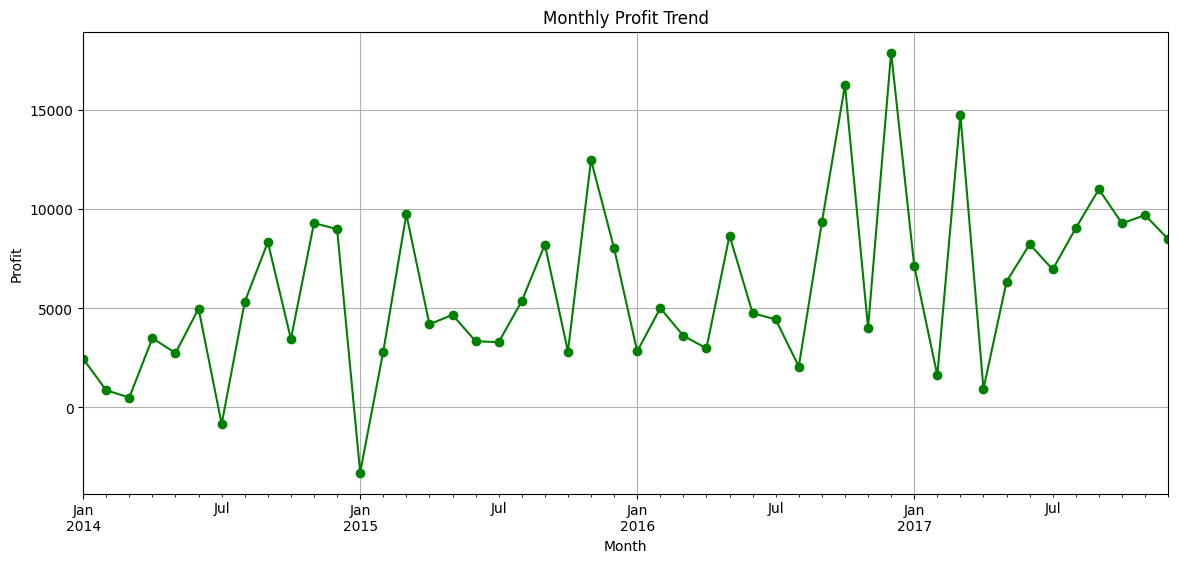

In [ ]:
monthly_profit = df.groupby('Month_Year')['Profit'].sum()

monthly_profit
plt.figure(figsize=(14,6))

monthly_profit.plot(marker='o', color='green')

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.grid(True)

plt.show()

### Observation

Monthly profit does not always follow the same trend as sales.

### Business Insight

Higher sales do not necessarily lead to higher profits. Discounts and product mix should be analyzed.

## Analysis 6: Top 10 Selling Products

This analysis identifies the top 10 products based on total sales. It helps determine which products contribute the most to overall revenue.

/tmp/ipykernel_3262/3241792401.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


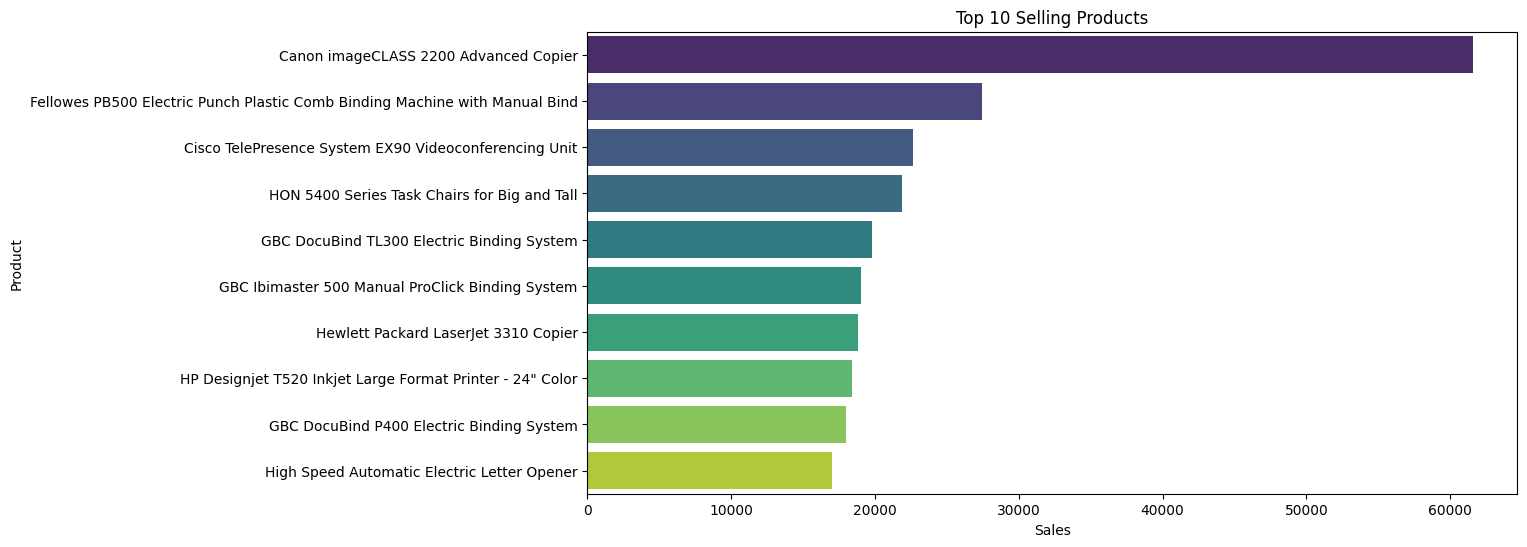

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

### Observation

A small number of products contribute significantly to total sales.

### Business Insight

Top-selling products should be prioritized in inventory planning and marketing campaigns.

## Analysis 7: Top 10 Customers

This analysis highlights the top 10 customers based on total purchase value. It helps identify valuable customers for customer retention strategies.

/tmp/ipykernel_3262/616908146.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


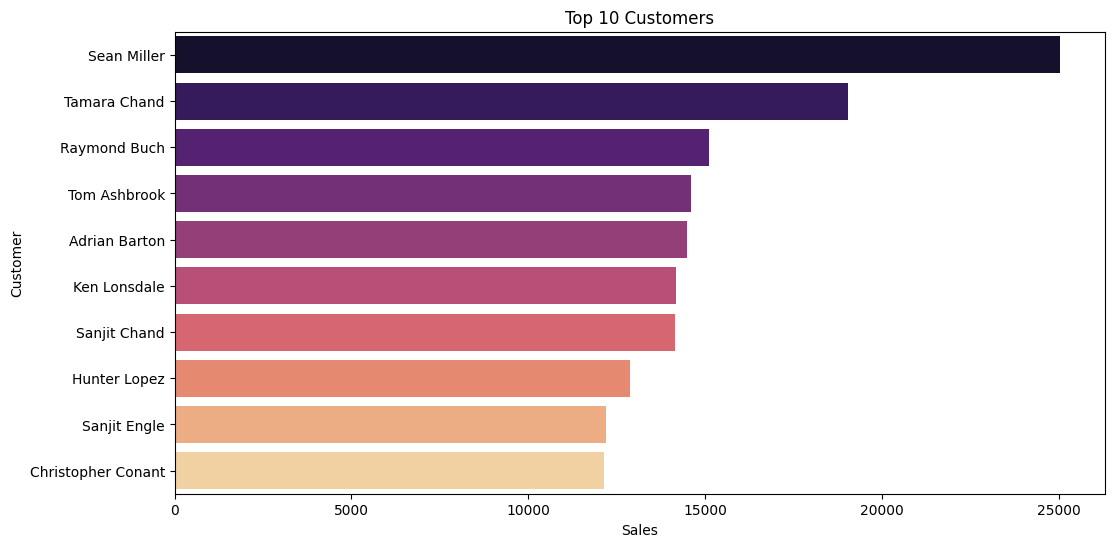

In [ ]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index,
    palette="magma"
)

plt.title("Top 10 Customers")
plt.xlabel("Sales")
plt.ylabel("Customer")

plt.show()

### Observation

A few customers generate a significant portion of total revenue.

### Business Insight

Maintaining strong relationships with high-value customers can improve long-term business growth.

## Analysis 8: Discount vs Profit

This analysis explores the relationship between discounts and profit. It helps determine whether higher discounts negatively impact business profitability.

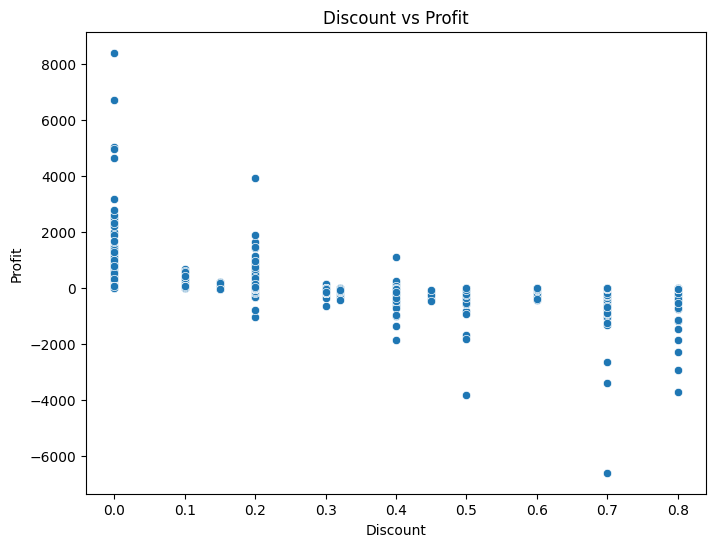

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

### Observation

- Higher discounts often lead to lower profits.
- Several orders with high discounts resulted in negative profits.

### Business Insight

The company should carefully monitor discount strategies to avoid unnecessary losses.

## Analysis 9: Correlation Heatmap

This analysis visualizes the correlation between numerical variables such as Sales, Quantity, Discount, and Profit. It helps identify relationships between key business metrics.

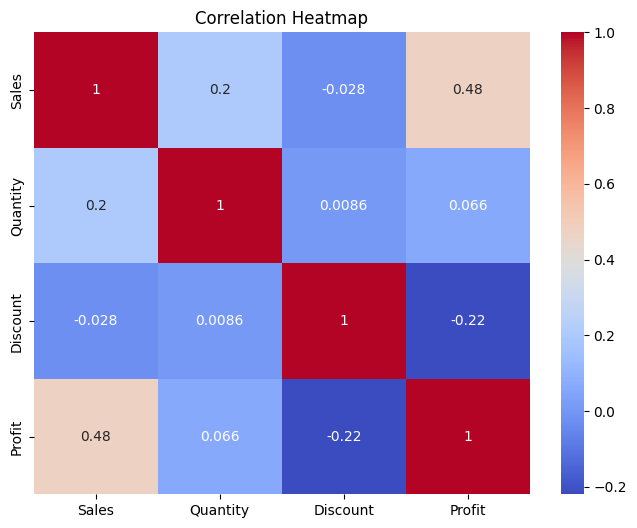

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales','Quantity','Discount','Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the relationship between numerical variables.

## Analysis 10: Sales Distribution

This analysis shows how sales values are distributed across all orders. It helps identify the presence of low-value and high-value transactions.

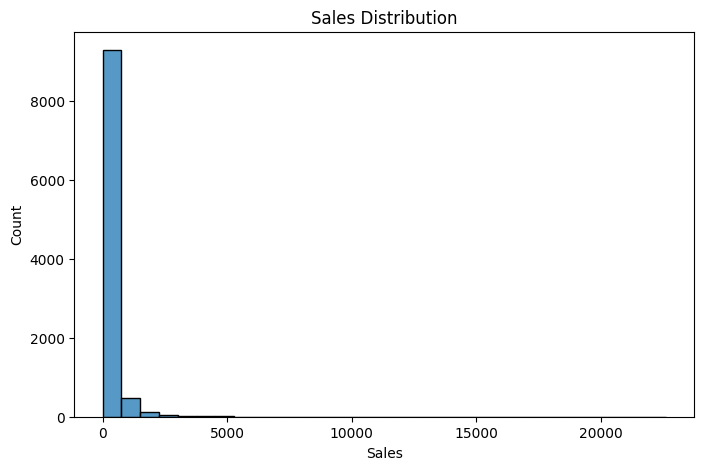

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")

plt.show()

## Analysis 11: Sales by Sub-Category

This analysis compares sales across different product sub-categories. It helps identify the strongest and weakest performing product groups.

/tmp/ipykernel_3262/1083436704.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


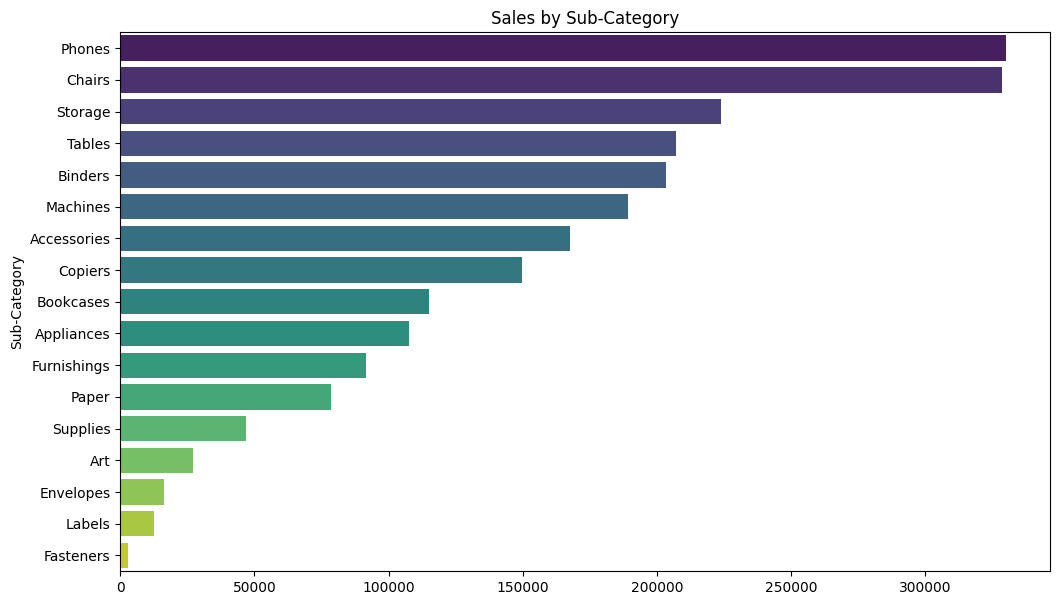

In [ ]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,7))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index,
    palette="viridis"
)

plt.title("Sales by Sub-Category")

plt.show()

### Observation

Some sub-categories contribute significantly more to sales than others.


# Business Recommendations

1. Increase investment in high-performing categories such as Technology.
2. Review discount policies to improve profitability.
3. Focus marketing campaigns on low-performing regions.
4. Retain high-value customers through loyalty programs.
5. Maintain sufficient inventory for top-selling products.
6. Optimize pricing strategies for low-profit products.

# Executive Summary

## Key Findings

- Technology generated the highest sales and profit.
- West region achieved the highest overall sales.
- High discounts were associated with lower profitability.
- A small number of products contributed significantly to total sales.
- Sales fluctuated across different months, indicating seasonal trends.

# Conclusion

This project analyzed retail sales data using Python and data analysis libraries to identify business trends and performance patterns.

The analysis revealed that Technology was the best-performing category, while higher discounts negatively impacted profitability. Regional and customer-level insights highlighted opportunities for improving sales, optimizing pricing strategies, and strengthening customer retention.

Overall, this project demonstrates the complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, and business insight generation.

# Skills Demonstrated

- Python
- Pandas
- NumPy
- Data Cleaning
- Data Analysis
- Exploratory Data Analysis (EDA)
- Data Visualization
- Matplotlib
- Seaborn
- Business Analysis